R2 Score: 0.639
RMSE: 5.35


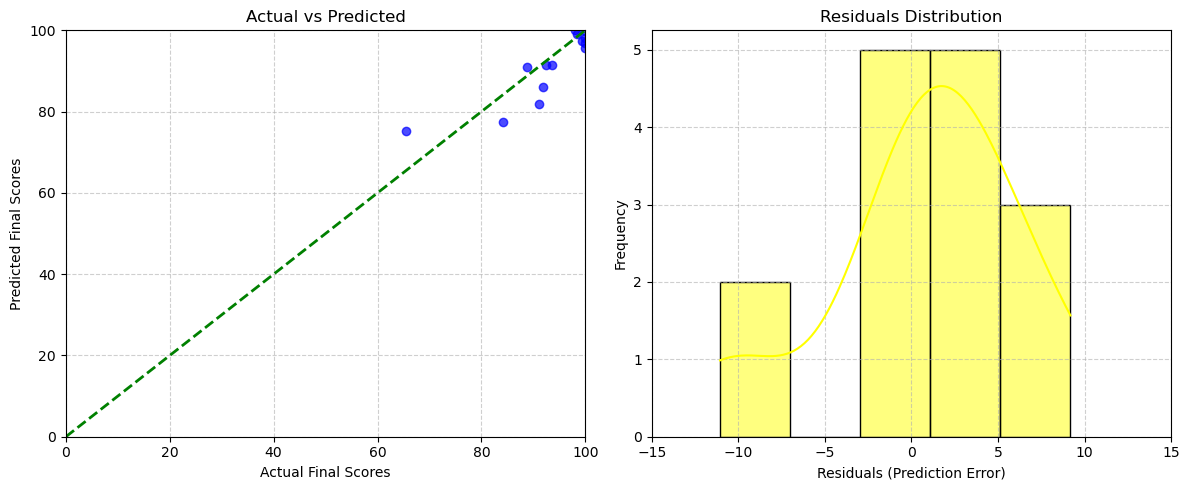

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)
n = 50
study_hours = np.random.uniform(1, 10, n)
attendance = np.random.uniform(60, 100, n)
previous_score = np.random.uniform(50, 95, n)

exam_score = 10 + 3*study_hours + 0.4*attendance + 0.5*previous_score + np.random.normal(0, 5, n)
exam_score = np.clip(exam_score, 40, 100) 

df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Attendance': attendance,
    'Previous_Score': previous_score,
    'Final_Score': exam_score
})

X = df[['Study_Hours', 'Attendance', 'Previous_Score']]
y = df['Final_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

print("R2 Score:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([0, 100], [0, 100], color='green', linestyle='--', linewidth=2) 
plt.xlabel('Actual Final Scores') 
plt.ylabel('Predicted Final Scores')
plt.title('Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 100) 
plt.ylim(0, 100)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='yellow', edgecolor='black') 
plt.xlabel('Residuals (Prediction Error)') 
plt.ylabel('Frequency') 
plt.title('Residuals Distribution')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-15, 15) 

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
df = pd.read_csv('salary_data_cleaned.csv')
print(df.columns)
print(df.head())

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel'],
      dtype='object')
                   Job Title              Salary Estimate  \
0             Data Scientist   $53K-$91K (Glassdoor est.)   
1  Healthcare Data Scientist  $63K-$112K (Glassdoor est.)   
2             Data Scientist   $80K-$90K (Glassdoor est.)   
3             Data Scientist   $56K-$97K (Glassdoor est.)   
4             Data Scientist  $86K-$143K (Glassdoor est.)   

                                     Job Description  Rating  \
0  Data Scientist\nLocation: Albuquerque, NM\nEdu...     3.8   
1  What You Will Do:\n\nI. General Summary\n\nThe...     3.4   
2  KnowBe4, Inc

--- Random Forest Performance ---
R2 Score Test: 0.998
RMSE Test: 1.85
MAE Test: 0.83

--- Top 10 Features Affecting Salary ---
         Feature  Importance
15    max_salary    0.918027
14    min_salary    0.076704
2   Company Name    0.000577
16     job_state    0.000563
6        Founded    0.000546
4   Headquarters    0.000408
5           Size    0.000399
0      Job Title    0.000361
18           age    0.000342
3       Location    0.000335


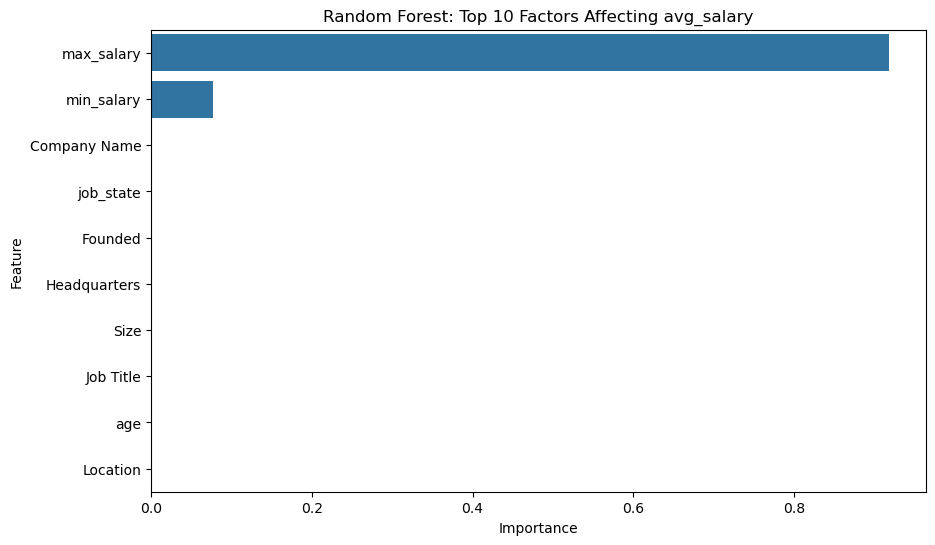

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor # <-- CHANGED
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('salary_data_cleaned.csv')

TARGET = 'avg_salary'
cols_to_drop = ['Salary Estimate', 'Job Description', 'company_txt']
df = df.drop(columns=cols_to_drop)

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42,
    n_jobs=-1 
)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print("--- Random Forest Performance ---")
print(f"R2 Score Test: {round(r2_score(y_test, y_pred), 3)}")
print(f"RMSE Test: {round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}")
print(f"MAE Test: {round(mean_absolute_error(y_test, y_pred), 2)}")

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\n Top 10 Features Affecting Salary ")
print(importance)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Random Forest: Top 10 Factors Affecting avg_salary')
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Save predictions
df['predicted_avg_salary_rf'] = model_rf.predict(X)
df.to_csv('salary_with_rf_predictions.csv', index=False)


In [15]:
!pip install pandas numpy matplotlib seaborn scikit-learn
